In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
DATASET_PATH = "C:/Users/Nikhil/raw-img"
class_names = {
    'cane': 'dog',
    'gatto': 'cat', 
    'cavallo': 'horse',
    'farfalla': 'butterfly',
    'elefante': 'elephant',
    'gallina': 'chicken',
    'mucca': 'cow',
    'pecora': 'sheep',
    'ragno': 'spider',
    'scoiattolo': 'squirrel'
}
print("Dataset Structure:")
print("-" * 35)
total = 0
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        english = class_names.get(folder, folder)
        print(f"{english:15} ({folder:12}) → {count} images")
        total += count
print("-" * 35)
print(f"Total images: {total}")

Dataset Structure:
-----------------------------------
dog             (cane        ) → 4863 images
horse           (cavallo     ) → 2623 images
elephant        (elefante    ) → 1446 images
butterfly       (farfalla    ) → 2112 images
chicken         (gallina     ) → 3098 images
cat             (gatto       ) → 1668 images
cow             (mucca       ) → 1866 images
sheep           (pecora      ) → 1820 images
spider          (ragno       ) → 4821 images
squirrel        (scoiattolo  ) → 1862 images
-----------------------------------
Total images: 26179


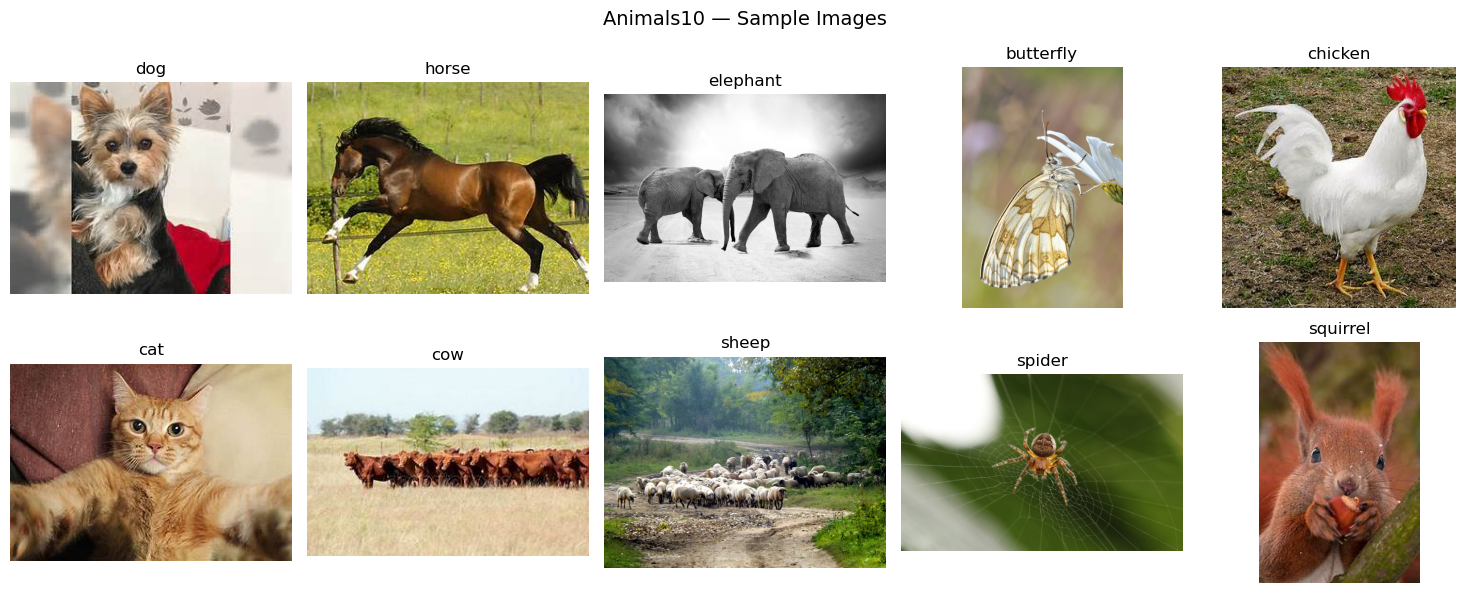

In [3]:
plt.figure(figsize=(15, 6))
folders = os.listdir(DATASET_PATH)

for i, folder in enumerate(folders):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        img_file = os.listdir(folder_path)[0]
        img_path = os.path.join(folder_path, img_file)
        img = Image.open(img_path).convert('RGB')
        
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(class_names.get(folder, folder))
        plt.axis('off')

plt.suptitle('Animals10 — Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
#KNN implementation
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import os

IMG_SIZE = 64 

X = []  # images
y = []  # labels

label_map = {name: idx for idx, name in enumerate(sorted(os.listdir(DATASET_PATH)))}
print("Label Map:", {class_names.get(k,k): v for k,v in label_map.items()})

print("\nLoading images...")
for folder, label_idx in label_map.items():
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    
    images_loaded = 0
    for img_file in os.listdir(folder_path):
        if images_loaded >= 500: 
            break
        try:
            img_path = os.path.join(folder_path, img_file)
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img))
            y.append(label_idx)
            images_loaded += 1
        except:
            continue
    print(f"{class_names.get(folder, folder):15} → {images_loaded} images loaded")

X = np.array(X)
y = np.array(y)

print(f"\nTotal images loaded: {len(X)}")
print(f"Image shape: {X[0].shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} images")
print(f"Testing set:  {len(X_test)} images")

X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print("\nData preprocessing complete!")

Label Map: {'dog': 0, 'horse': 1, 'elephant': 2, 'butterfly': 3, 'chicken': 4, 'cat': 5, 'cow': 6, 'sheep': 7, 'spider': 8, 'squirrel': 9}

Loading images...
dog             → 500 images loaded
horse           → 500 images loaded
elephant        → 500 images loaded
butterfly       → 500 images loaded
chicken         → 500 images loaded
cat             → 500 images loaded
cow             → 500 images loaded
sheep           → 500 images loaded
spider          → 500 images loaded
squirrel        → 500 images loaded

Total images loaded: 5000
Image shape: (64, 64, 3)

Training set: 4000 images
Testing set:  1000 images

Data preprocessing complete!


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import time

X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat  = X_test_norm.reshape(len(X_test_norm), -1)

print(f"Training data shape: {X_train_flat.shape}")
print(f"Testing data shape:  {X_test_flat.shape}")

print("\nTraining KNN (k=5)...")
start_time = time.time()

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)

train_time = time.time() - start_time
print(f"Training Complete! Time: {train_time:.2f} seconds")

print("\nPredicting...")
y_pred_knn = knn.predict(X_test_flat)

accuracy  = accuracy_score(y_test, y_pred_knn) * 100
precision = precision_score(y_test, y_pred_knn, average='macro') * 100
recall    = recall_score(y_test, y_pred_knn, average='macro') * 100

print("\n" + "="*40)
print("KNN RESULTS:")
print("="*40)
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print("="*40)

Training data shape: (4000, 12288)
Testing data shape:  (1000, 12288)

Training KNN (k=5)...
Training Complete! Time: 0.19 seconds

Predicting...

KNN RESULTS:
Accuracy  : 23.20%
Precision : 29.92%
Recall    : 23.20%


In [6]:
#CNN implementation
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import time

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

model_cnn = Sequential([
    tf.keras.Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
import time

start_time = time.time()

history_cnn = model_cnn.fit(
    X_train_norm, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_norm, y_test_cat),
    verbose=1
)

train_time = time.time() - start_time
print(f"Training Complete! Time: {train_time:.2f} seconds")

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 376ms/step - accuracy: 0.7270 - loss: 0.7546 - val_accuracy: 0.5410 - val_loss: 1.6083
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 396ms/step - accuracy: 0.7697 - loss: 0.6553 - val_accuracy: 0.5390 - val_loss: 1.6188
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 92s 476ms/step - accuracy: 0.7965 - loss: 0.5715 - val_accuracy: 0.4600 - val_loss: 2.1310
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 426ms/step - accuracy: 0.8098 - loss: 0.4937 - val_accuracy: 0.4450 - val_loss: 2.0898
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 54s 433ms/step - accuracy: 0.8365 - loss: 0.4649 - val_accuracy: 0.5120 - val_loss: 1.8300
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 410ms/step - accuracy: 0.8555 - loss: 0.4168 - val_accuracy: 0.5150 - val_loss: 1.9394
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.8740 - loss: 0.3605 - val_accuracy: 0.5380 - val_loss: 2.0934
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 381ms/step - accuracy: 0.8745 - loss: 0

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred_prob = model_cnn.predict(X_test_norm, verbose=0)
y_pred_cnn  = np.argmax(y_pred_prob, axis=1)

accuracy  = accuracy_score(y_test, y_pred_cnn) * 100
precision = precision_score(y_test, y_pred_cnn, average='macro') * 100
recall    = recall_score(y_test, y_pred_cnn, average='macro') * 100

print("=" * 40)
print("CNN RESULTS:")
print("=" * 40)
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print("=" * 40)

CNN RESULTS:
Accuracy  : 54.80%
Precision : 56.23%
Recall    : 54.80%


In [13]:
#R-CNN implementation
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from PIL import Image
import numpy as np
import time

print("Resizing images for ResNet50 (224x224)...")

def resize_for_resnet(images):
    resized = []
    for img in images:
        img_pil = Image.fromarray((img * 255).astype(np.uint8))
        img_pil = img_pil.resize((224, 224))
        resized.append(np.array(img_pil))
    return np.array(resized)

X_train_resnet = resize_for_resnet(X_train_norm)
X_test_resnet  = resize_for_resnet(X_test_norm)

print("Loading ResNet50 (pre-trained on ImageNet)...")
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

print("Extracting features from training images...")
X_train_resnet = preprocess_input(X_train_resnet.astype(np.float32))
X_test_resnet  = preprocess_input(X_test_resnet.astype(np.float32))

start_time = time.time()
X_train_features = base_model.predict(X_train_resnet, batch_size=32, verbose=1)
X_test_features  = base_model.predict(X_test_resnet,  batch_size=32, verbose=1)
print(f"Feature extraction complete! Time: {time.time()-start_time:.2f} seconds")

print("Training classifier...")
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train_features, y_train)

y_pred_rcnn = classifier.predict(X_test_features)

accuracy  = accuracy_score(y_test, y_pred_rcnn) * 100
precision = precision_score(y_test, y_pred_rcnn, average='macro') * 100
recall    = recall_score(y_test, y_pred_rcnn, average='macro') * 100

print("=" * 40)
print("R-CNN RESULTS:")
print("=" * 40)
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print("=" * 40)

Resizing images for ResNet50 (224x224)...
Loading ResNet50 (pre-trained on ImageNet)...
Extracting features from training images...
125/125 ━━━━━━━━━━━━━━━━━━━━ 750s 6s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step
Feature extraction complete! Time: 972.05 seconds
Training classifier...
R-CNN RESULTS:
Accuracy  : 93.50%
Precision : 93.53%
Recall    : 93.50%


In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import time

print("Building Mask R-CNN style model...")

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base.trainable = False  

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(10, activation='softmax')(x)

mask_rcnn_model = Model(inputs=base.input, outputs=output)

mask_rcnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built successfully!")
mask_rcnn_model.summary()

Building Mask R-CNN style model...


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_7352\678644146.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Model built successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
from tensorflow.keras.utils import to_categorical
import time

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

X_train_mobilenet = X_train_norm
X_test_mobilenet  = X_test_norm

start_time = time.time()

history_mask = mask_rcnn_model.fit(
    X_train_mobilenet, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_mobilenet, y_test_cat),
    verbose=1
)

train_time = time.time() - start_time
print(f"Training Complete! Time: {train_time:.2f} seconds")

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 306ms/step - accuracy: 0.4837 - loss: 1.5924 - val_accuracy: 0.5940 - val_loss: 1.1837
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - accuracy: 0.6905 - loss: 0.9294 - val_accuracy: 0.6170 - val_loss: 1.1219
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 208ms/step - accuracy: 0.7707 - loss: 0.6800 - val_accuracy: 0.6310 - val_loss: 1.1170
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 214ms/step - accuracy: 0.8400 - loss: 0.4868 - val_accuracy: 0.6470 - val_loss: 1.1112
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 210ms/step - accuracy: 0.8913 - loss: 0.3589 - val_accuracy: 0.6450 - val_loss: 1.1170
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.9262 - loss: 0.2583 - val_accuracy: 0.6440 - val_loss: 1.1628
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 206ms/step - accuracy: 0.9408 - loss: 0.2108 - val_accuracy: 0.6330 - val_loss: 1.2448
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 214ms/step - accuracy: 0.9535 - loss: 0

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

y_pred_prob_mask = mask_rcnn_model.predict(X_test_mobilenet, verbose=0)
y_pred_mask      = np.argmax(y_pred_prob_mask, axis=1)

accuracy  = accuracy_score(y_test, y_pred_mask) * 100
precision = precision_score(y_test, y_pred_mask, average='macro') * 100
recall    = recall_score(y_test, y_pred_mask, average='macro') * 100

print("=" * 40)
print("MASK R-CNN RESULTS:")
print("=" * 40)
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print("=" * 40)

MASK R-CNN RESULTS:
Accuracy  : 62.50%
Precision : 63.22%
Recall    : 62.50%


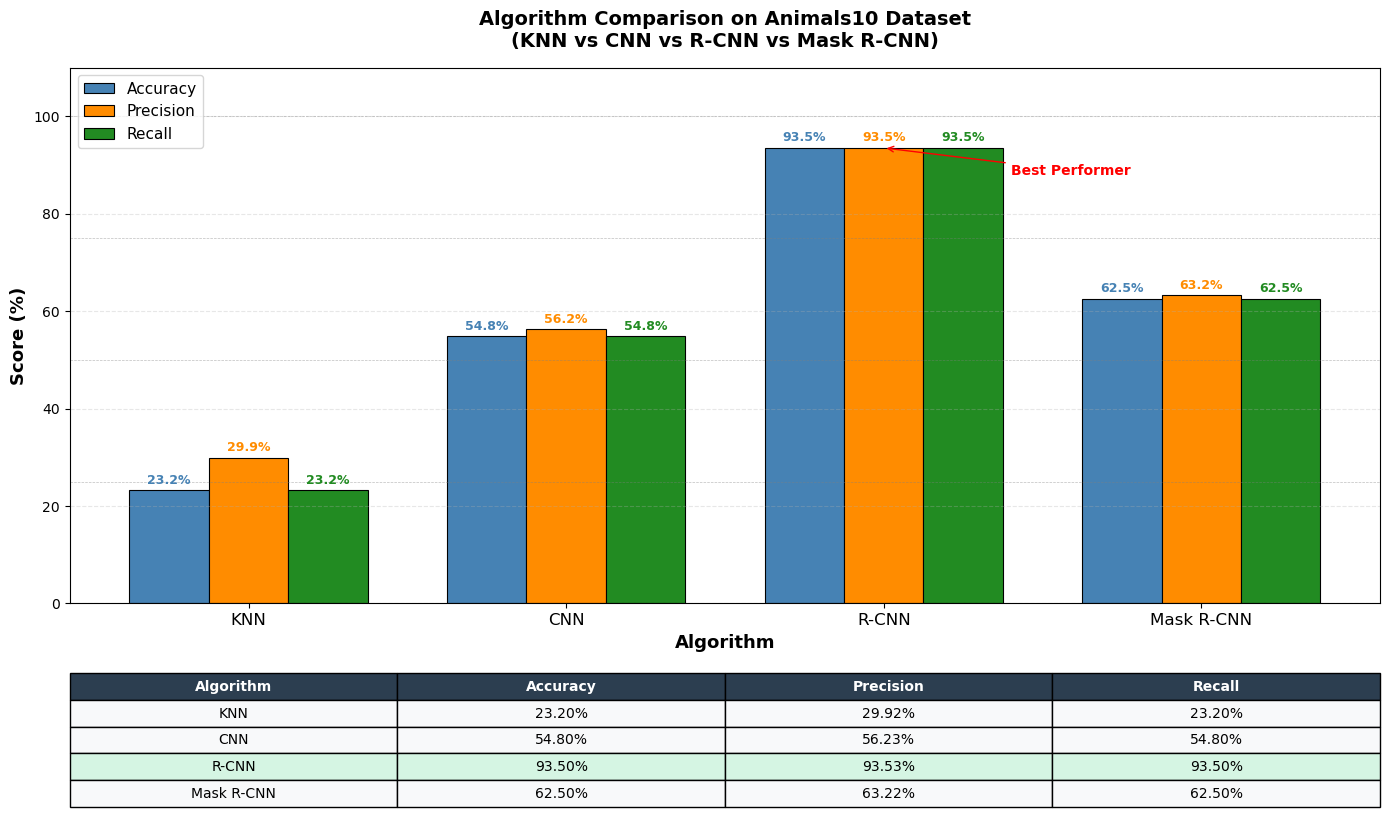

In [18]:
import matplotlib.pyplot as plt
import numpy as np

algorithms = ['KNN', 'CNN', 'R-CNN', 'Mask R-CNN']
accuracy   = [23.20, 54.80, 93.50, 62.50]
precision  = [29.92, 56.23, 93.53, 63.22]
recall     = [23.20, 54.80, 93.50, 62.50]

x     = np.arange(len(algorithms))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width, accuracy,  width, label='Accuracy',  color='steelblue',   edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x,         precision, width, label='Precision', color='darkorange',  edgecolor='black', linewidth=0.8)
bars3 = ax.bar(x + width, recall,    width, label='Recall',    color='forestgreen', edgecolor='black', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='steelblue')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkorange')

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='forestgreen')

for y in [25, 50, 75, 100]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.annotate('Best Performer', xy=(2, 93.50), xytext=(2.4, 88),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Algorithm', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=13, fontweight='bold')
ax.set_title('Algorithm Comparison on Animals10 Dataset\n(KNN vs CNN vs R-CNN vs Mask R-CNN)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, fontsize=12)
ax.set_ylim(0, 110)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

table_data = [
    ['KNN',        '23.20%', '29.92%', '23.20%'],
    ['CNN',        '54.80%', '56.23%', '54.80%'],
    ['R-CNN',      '93.50%', '93.53%', '93.50%'],
    ['Mask R-CNN', '62.50%', '63.22%', '62.50%'],
]
col_labels = ['Algorithm', 'Accuracy', 'Precision', 'Recall']
table = ax.table(cellText=table_data, colLabels=col_labels,
                 cellLoc='center', loc='bottom', bbox=[0, -0.38, 1, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 3:  # R-CNN row — highlight best
        cell.set_facecolor('#D5F5E3')
    else:
        cell.set_facecolor('#F8F9FA')

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()